## lagrange插值法  
$l_i=\Pi_{j=0,i\not = j}^{n}\frac{x-x_j}{x_i-x_j}$  
$f(x)=\sum_{i=0}^{n}y_i l_i$


Matplotlib is building the font cache; this may take a moment.
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25554 (\N{CJK UNIFIED IDEOGRAPH-63D2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.

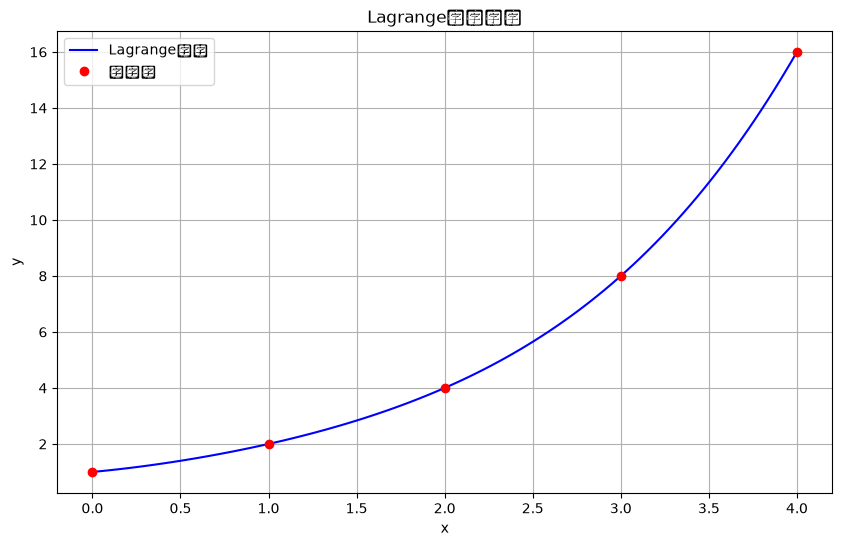

P(2.5) = 5.6484


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def lagrange_interpolation(x_data, y_data, x_eval):
    """
    拉格朗日插值函数
    
    参数:
        x_data: 已知点的x坐标列表
        y_data: 已知点的y坐标列表
        x_eval: 要计算的点或数组
    
    返回:
        插值结果
    """
    x_data = np.array(x_data, dtype=float)
    y_data = np.array(y_data, dtype=float)
    
    if np.isscalar(x_eval):
        x_eval = np.array([x_eval])
    else:
        x_eval = np.array(x_eval, dtype=float)
    
    n = len(x_data)
    result = np.zeros_like(x_eval, dtype=float)
    
    for i in range(n):
        # 计算第i个基函数
        basis = np.ones_like(x_eval, dtype=float)
        for j in range(n):
            if j != i:
                basis *= (x_eval - x_data[j]) / (x_data[i] - x_data[j])
        
        # 累加
        result += y_data[i] * basis
    
    return result[0] if len(result) == 1 else result

# 使用示例
if __name__ == "__main__":
    # 输入数据点
    x_data = [0, 1, 2, 3, 4]
    y_data = [1, 2, 4, 8, 16]
    
    # 创建插值函数
    x_plot = np.linspace(min(x_data), max(x_data), 100)
    y_plot = lagrange_interpolation(x_data, y_data, x_plot)
    
    # 绘制结果
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, y_plot, 'b-', label='Lagrange插值')
    plt.plot(x_data, y_data, 'ro', label='数据点')
    plt.grid(True)
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Lagrange插值示例')
    plt.show()
    
    # 计算特定点
    x_test = 2.5
    y_test = lagrange_interpolation(x_data, y_data, x_test)
    print(f"P({x_test}) = {y_test:.4f}")

## 样条插值法

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d

def simple_spline_demo():
    """使用scipy的简单样条插值示例"""
    # 数据点
    x_data = np.array([0, 1, 2, 3, 4, 5])
    y_data = np.array([0, 2, 1, 3, 2, 4])
    
    # 创建不同类型的样条插值
    cs_natural = CubicSpline(x_data, y_data, bc_type='natural')  # 自然三次样条
    cs_clamped = CubicSpline(x_data, y_data, bc_type='clamped')  # 固定边界
    linear = interp1d(x_data, y_data, kind='linear')  # 线性插值
    quadratic = interp1d(x_data, y_data, kind='quadratic')  # 二次插值
    
    # 生成绘图点
    x_plot = np.linspace(0, 5, 200)
    
    # 绘图
    plt.figure(figsize=(12, 6))
    plt.plot(x_data, y_data, 'ko', label='数据点', markersize=10, zorder=5)
    plt.plot(x_plot, cs_natural(x_plot), 'b-', label='自然三次样条', linewidth=2)
    plt.plot(x_plot, cs_clamped(x_plot), 'g--', label='固定边界三次样条', linewidth=2)
    plt.plot(x_plot, linear(x_plot), 'r-.', label='线性插值', linewidth=2)
    plt.plot(x_plot, quadratic(x_plot), 'm:', label='二次插值', linewidth=2)
    
    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('scipy样条插值比较')
    plt.legend()
    plt.show()
    
    # 计算特定点
    x_test = 2.5
    print(f"在 x = {x_test} 处的插值结果：")
    print(f"  自然三次样条: {cs_natural(x_test):.4f}")
    print(f"  固定边界三次样条: {cs_clamped(x_test):.4f}")
    print(f"  线性插值: {linear(x_test):.4f}")
    print(f"  二次插值: {quadratic(x_test):.4f}")
    
    # 计算导数
    print(f"\n在 x = {x_test} 处的导数：")
    print(f"  一阶导数: {cs_natural(x_test, 1):.4f}")
    print(f"  二阶导数: {cs_natural(x_test, 2):.4f}")


# 交互式输入示例
def interactive_spline():
    """交互式样条插值"""
    print("请输入数据点（每行一个点，格式：x y）")
    print("输入空行结束")
    
    x_data = []
    y_data = []
    
    while True:
        line = input().strip()
        if not line:
            break
        try:
            x, y = map(float, line.split())
            x_data.append(x)
            y_data.append(y)
        except:
            print("输入格式错误，请重新输入")
    
    if len(x_data) < 3:
        print("至少需要3个数据点")
        return
    
    # 排序数据点
    sorted_pairs = sorted(zip(x_data, y_data))
    x_data = [p[0] for p in sorted_pairs]
    y_data = [p[1] for p in sorted_pairs]
    
    # 创建样条插值
    cs = CubicSpline(x_data, y_data)
    
    # 绘图
    x_plot = np.linspace(min(x_data), max(x_data), 200)
    y_plot = cs(x_plot)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, 'ro', label='数据点', markersize=8)
    plt.plot(x_plot, y_plot, 'b-', label='三次样条插值', linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('三次样条插值结果')
    plt.legend()
    plt.show()
    
    # 计算特定点
    while True:
        x_input = input("\n请输入要计算的点（输入q退出）：").strip()
        if x_input.lower() == 'q':
            break
        try:
            x_val = float(x_input)
            y_val = cs(x_val)
            print(f"P({x_val}) = {y_val:.6f}")
        except:
            print("请输入有效的数字")


if __name__ == "__main__":
    print("样条插值示例")
    print("=" * 50)
    
    # 基础示例
    x_data = [0, 1, 2, 3, 4, 5]
    y_data = [0, 2, 1, 3, 2, 4]
    
    # 使用手动实现
    print("使用手动实现的三次样条：")
    x_test = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
    y_test = cubic_spline(x_data, y_data, x_test)
    for x, y in zip(x_test, y_test):
        print(f"  P({x}) = {y:.4f}")
    
    plot_spline_comparison()
    
    # 使用scipy版本
    print("\n使用scipy库：")
    simple_spline_demo()

样条插值示例
使用手动实现的三次样条：


NameError: name 'cubic_spline' is not defined

## 龙格现象  
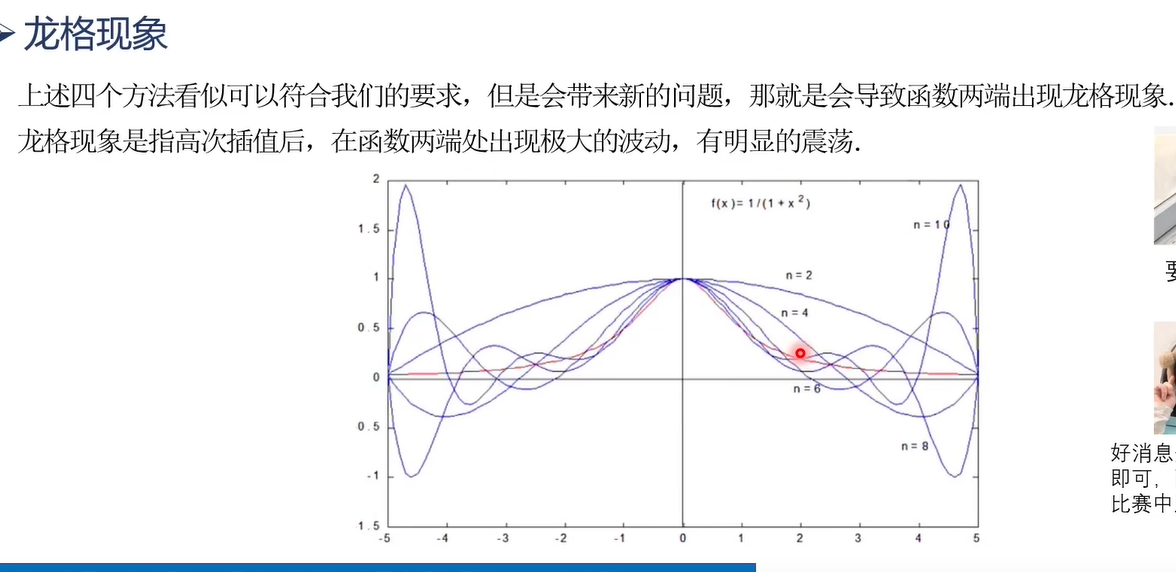

### 解决方法：分段线性三次样条插值

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

def piecewise_cubic_spline(x_data, y_data, x_eval, segment_size=5):
    """
    分段三次样条插值
    
    参数:
        x_data: 已知点的x坐标
        y_data: 已知点的y坐标
        x_eval: 要计算的点或数组
        segment_size: 每段包含的数据点数（默认5个点）
    
    返回:
        插值结果
    """
    x_data = np.array(x_data, dtype=float)
    y_data = np.array(y_data, dtype=float)
    
    # 排序数据
    sort_idx = np.argsort(x_data)
    x_data = x_data[sort_idx]
    y_data = y_data[sort_idx]
    
    n = len(x_data)
    
    # 创建分段
    segments = []
    for i in range(0, n-1, segment_size-1):
        end = min(i + segment_size, n)
        if end - i >= 2:  # 至少2个点
            segments.append((i, end-1))
    
    # 为每段创建样条插值
    splines = []
    for start, end in segments:
        x_seg = x_data[start:end+1]
        y_seg = y_data[start:end+1]
        
        if len(x_seg) >= 3:
            # 使用三次样条
            spline = CubicSpline(x_seg, y_seg, bc_type='natural')
        else:
            # 点太少，使用线性插值
            from scipy.interpolate import interp1d
            spline = interp1d(x_seg, y_seg, kind='linear', fill_value='extrapolate')
        
        splines.append((spline, x_seg[0], x_seg[-1]))
    
    # 计算插值
    if np.isscalar(x_eval):
        x_eval = np.array([x_eval])
    else:
        x_eval = np.array(x_eval, dtype=float)
    
    result = np.zeros_like(x_eval, dtype=float)
    
    for i, x in enumerate(x_eval):
        # 找到对应的段
        for spline, x_min, x_max in splines:
            if x_min <= x <= x_max:
                result[i] = float(spline(x))
                break
        else:
            # 边界外处理
            if x < x_data[0]:
                result[i] = float(splines[0][0](x))
            else:
                result[i] = float(splines[-1][0](x))
    
    return result[0] if len(result) == 1 else result


def plot_piecewise_spline(x_data, y_data, segment_size=5, num_points=500):
    """
    绘制分段三次样条插值结果
    
    参数:
        x_data: 已知点的x坐标
        y_data: 已知点的y坐标
        segment_size: 每段包含的数据点数
        num_points: 绘图采样点数
    """
    # 生成绘图点
    x_min, x_max = min(x_data), max(x_data)
    margin = (x_max - x_min) * 0.1
    x_plot = np.linspace(x_min - margin, x_max + margin, num_points)
    
    # 计算插值
    y_plot = piecewise_cubic_spline(x_data, y_data, x_plot, segment_size)
    
    # 绘图
    plt.figure(figsize=(10, 6))
    
    # 绘制插值曲线
    plt.plot(x_plot, y_plot, 'b-', label='分段三次样条', linewidth=2)
    
    # 绘制数据点
    plt.plot(x_data, y_data, 'ro', label='数据点', markersize=8, zorder=5)
    
    # 标记分段点
    x_data_sorted = np.sort(x_data)
    for i in range(segment_size-1, len(x_data_sorted)-1, segment_size-1):
        plt.axvline(x=x_data_sorted[i], color='g', linestyle='--', 
                   alpha=0.5, linewidth=1.5, 
                   label='分段点' if i == segment_size-1 else '')
    
    plt.grid(True, alpha=0.3)
    plt.xlabel('x轴')
    plt.ylabel('y轴')
    plt.title(f'分段三次样条插值（每段{segment_size}个点）')
    plt.legend()
    plt.show()



示例1：简单数据点
数据点： [(0, 0), (1, 2), (2, 1), (3, 3), (4, 2), (5, 4), (6, 3), (7, 5), (8, 4), (9, 6), (10, 5)]

特定点的插值结果：
  P(1.5) = 1.5000
  P(3.7) = 1.9430
  P(5.2) = 4.0880
  P(8.9) = 5.7010


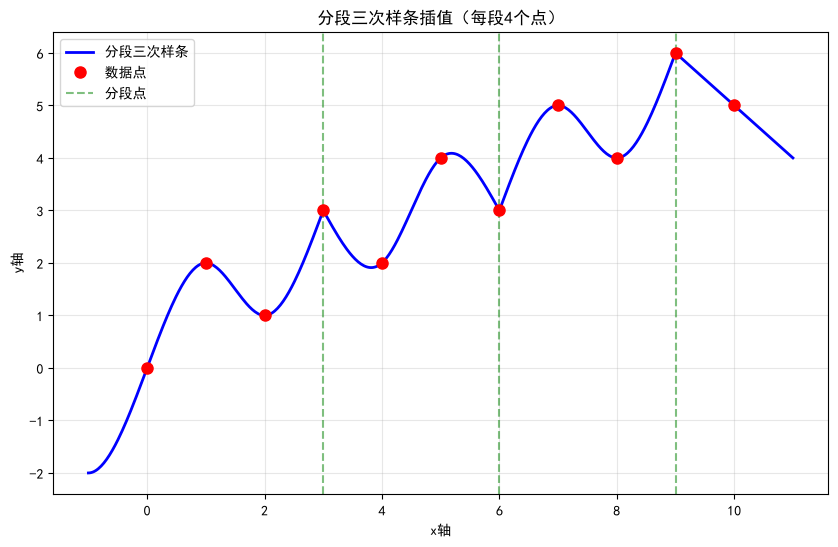


示例2：龙格函数（展示减少振荡效果）


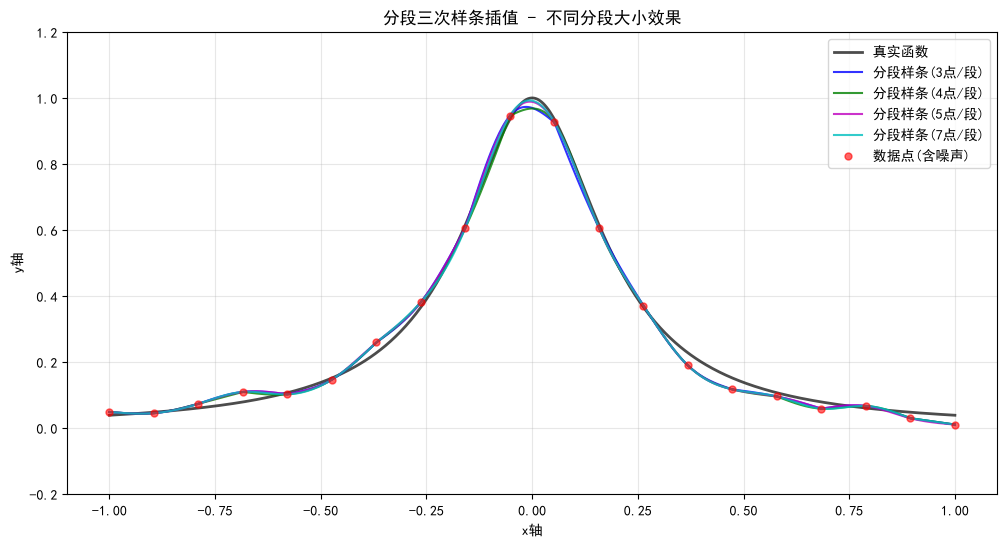

In [10]:

def main():
    """主函数 - 自动运行示例"""
    
    # 示例1：简单数据点
    print("示例1：简单数据点")
    print("=" * 40)
    x_data = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    y_data = [0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5]
    
    # 计算特定点
    test_points = [1.5, 3.7, 5.2, 8.9]
    results = piecewise_cubic_spline(x_data, y_data, test_points, segment_size=4)
    
    print("数据点：", list(zip(x_data, y_data)))
    print("\n特定点的插值结果：")
    for x, y in zip(test_points, results):
        print(f"  P({x}) = {y:.4f}")
    
    # 绘图
    plot_piecewise_spline(x_data, y_data, segment_size=4)
    
    # 示例2：龙格函数（展示减少振荡效果）
    print("\n示例2：龙格函数（展示减少振荡效果）")
    print("=" * 40)
    
    def runge(x):
        return 1 / (1 + 25 * x**2)
    
    # 生成数据点
    n_points = 20
    x_runge = np.linspace(-1, 1, n_points)
    y_runge = runge(x_runge)
    
    # 添加噪声
    np.random.seed(42)
    noise = np.random.normal(0, 0.02, n_points)
    y_runge_noisy = y_runge + noise
    
    # 绘图
    plt.figure(figsize=(12, 6))
    
    # 真实函数
    x_plot = np.linspace(-1, 1, 500)
    y_true = runge(x_plot)
    plt.plot(x_plot, y_true, 'k-', label='真实函数', linewidth=2, alpha=0.7)
    
    # 不同分段大小的插值
    colors = ['b-', 'g-', 'm-', 'c-']
    segment_sizes = [3, 4, 5, 7]
    
    for seg_size, color in zip(segment_sizes, colors):
        y_interp = piecewise_cubic_spline(x_runge, y_runge_noisy, x_plot, seg_size)
        plt.plot(x_plot, y_interp, color, 
                label=f'分段样条({seg_size}点/段)', 
                linewidth=1.5, alpha=0.8)
    
    # 数据点
    plt.plot(x_runge, y_runge_noisy, 'ro', label='数据点(含噪声)', 
            markersize=5, alpha=0.6)
    
    plt.ylim([-0.2, 1.2])
    plt.grid(True, alpha=0.3)
    plt.xlabel('x轴')
    plt.ylabel('y轴')
    plt.title('分段三次样条插值 - 不同分段大小效果')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()